In [1]:
# For each (DQN, MFI) records CSV, plot the cumulative number of unique itemIDs
# used across ALL subjects up through step k, for k = 1..TEST_LENGTH.
# Interpretation: bank coverage as the test progresses.
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP027").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


def load_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"NOT FOUND (skipped): {path}")
        return None
    return pd.read_csv(path)


def cumulative_unique(records: pd.DataFrame, max_step: int) -> pd.DataFrame:
    """Return a DataFrame with columns [step, unique_items] where unique_items[k]
    is the number of distinct itemIDs that appear at least once across all
    subjects during steps 1..k."""
    steps = records["step"].round().astype(int)
    items = records["itemID"].round().astype(int)
    seen: set[int] = set()
    rows = []
    for k in range(1, max_step + 1):
        step_items = items[steps == k].unique()
        seen.update(int(x) for x in step_items)
        rows.append({"step": k, "unique_items": len(seen)})
    return pd.DataFrame(rows)


ROOT = find_project_root()
EXP027_RESULTS = ROOT / "EXP027" / "results"

BANK_ID = 1
GAMMA = "0.1"
REAL_FORM = "LNIRT_CredentialForm1"
TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]

print(f"Project root : {ROOT}")
print(f"Results dir  : {EXP027_RESULTS}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir  : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results


In [2]:
# Load records CSVs. Only Python-side MFI variants (matched-seed with DQN).
dqn_sim_eap = load_if_exists(
    EXP027_RESULTS / f"records_uncor_{BANK_ID}_DQN_EAP_unif_gamma_{GAMMA}.csv"
)
mfi_sim_eap = load_if_exists(
    EXP027_RESULTS / f"records_uncor_{BANK_ID}_MFI_EAP_unif_python.csv"
)
dqn_sim_mle = load_if_exists(
    EXP027_RESULTS / f"records_uncor_{BANK_ID}_DQN_MLE_gamma_{GAMMA}.csv"
)
mfi_sim_mle = load_if_exists(
    EXP027_RESULTS / f"records_uncor_{BANK_ID}_MFI_MLE_python.csv"
)
dqn_real_mle = load_if_exists(
    EXP027_RESULTS / f"records_real_{REAL_FORM}_DQN_MLE_gamma_{GAMMA}.csv"
)
mfi_real_mle = load_if_exists(
    EXP027_RESULTS / f"records_real_{REAL_FORM}_MFI_MLE.csv"
)

# Bank sizes (used for reference lines / titles).
sim_bank_path = (
    ROOT / "data" / "uncorrelated_banks" / f"item_bank_uncor_{BANK_ID}.csv"
)
real_bank_path = ROOT / "data" / REAL_FORM / "real item bank.csv"
sim_bank_size = len(pd.read_csv(sim_bank_path))
real_bank_size = len(pd.read_csv(real_bank_path))

print(f"sim  bank size: {sim_bank_size}")
print(f"real bank size: {real_bank_size}")

panels = [
    {
        "title": (
            f"Simulated EAP: unique items used (uncor bank {BANK_ID}, gamma={GAMMA})"
        ),
        "bank_size": sim_bank_size,
        "series": [
            (mfi_sim_eap, "MFI (EAP, uniform prior)", "steelblue", "--"),
            (dqn_sim_eap, f"DQN (EAP, gamma={GAMMA})", "tomato", "-"),
        ],
        "suffix": "sim_EAP",
    },
    {
        "title": (
            f"Simulated MLE: unique items used (uncor bank {BANK_ID}, gamma={GAMMA})"
        ),
        "bank_size": sim_bank_size,
        "series": [
            (mfi_sim_mle, "MFI (MLE)", "steelblue", "--"),
            (dqn_sim_mle, f"DQN (MLE, gamma={GAMMA})", "tomato", "-"),
        ],
        "suffix": "sim_MLE",
    },
    {
        "title": (
            f"Real MLE: unique items used ({REAL_FORM}, gamma={GAMMA})"
        ),
        "bank_size": real_bank_size,
        "series": [
            (mfi_real_mle, "MFI (MLE)", "steelblue", "--"),
            (dqn_real_mle, f"DQN (MLE, gamma={GAMMA})", "tomato", "-"),
        ],
        "suffix": "real_MLE",
    },
]

sim  bank size: 500
real bank size: 170


In [3]:
# Compute cumulative unique item counts for every (panel, series) pair.
curves: dict[tuple[str, str], pd.DataFrame] = {}
for panel in panels:
    for data, label, *_ in panel["series"]:
        if data is None:
            continue
        curves[(panel["suffix"], label)] = cumulative_unique(data, TEST_LENGTH)

# Quick sanity peek: coverage at key steps for each series.
peek_rows = []
for (suffix, label), curve in curves.items():
    peek_rows.append(
        {
            "dataset": suffix,
            "method": label,
            **{k: int(curve.loc[curve["step"] == k, "unique_items"].iloc[0]) for k in KEY_STEPS},
        }
    )
peek = pd.DataFrame(peek_rows).set_index(["dataset", "method"])
peek.columns.name = "step"
print(peek.to_string())

step                               10   20   30   40
dataset  method                                     
sim_EAP  MFI (EAP, uniform prior)  60  119  162  205
         DQN (EAP, gamma=0.1)      32   57   73   89
sim_MLE  MFI (MLE)                 65  125  168  215
         DQN (MLE, gamma=0.1)      33   66   85  103
real_MLE MFI (MLE)                 34   64   79   98
         DQN (MLE, gamma=0.1)      23   38   53   64


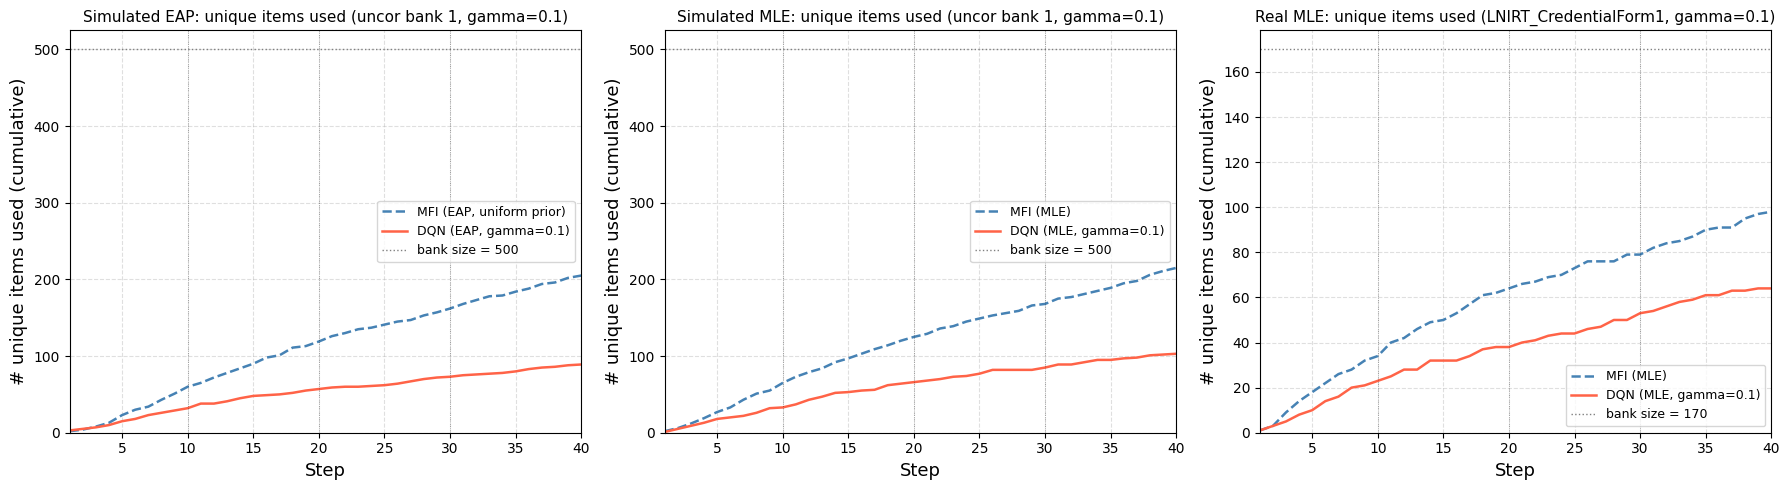

Saved combined figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/unique_items_used_gamma_0.1.png


In [4]:
# 1x3 figure with independent y-axis per panel (bank sizes differ).
figure, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for axis, panel in zip(axes, panels):
    for data, label, color, line_style in panel["series"]:
        if data is None:
            continue
        curve = curves[(panel["suffix"], label)]
        axis.plot(
            curve["step"],
            curve["unique_items"],
            label=label,
            color=color,
            linestyle=line_style,
            linewidth=1.8,
        )
    axis.axhline(
        panel["bank_size"],
        color="gray",
        linestyle=":",
        linewidth=1.0,
        label=f"bank size = {panel['bank_size']}",
    )
    for step in KEY_STEPS:
        axis.axvline(step, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    axis.set_xlabel("Step", fontsize=13)
    axis.set_ylabel("# unique items used (cumulative)", fontsize=13)
    axis.set_title(panel["title"], fontsize=11)
    axis.legend(fontsize=9, loc="best")
    axis.grid(True, linestyle="--", alpha=0.4)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.set_xlim(1, TEST_LENGTH)
    axis.set_ylim(bottom=0)

figure.tight_layout()
EXP027_RESULTS.mkdir(parents=True, exist_ok=True)
combined_path = EXP027_RESULTS / f"unique_items_used_gamma_{GAMMA}.png"
figure.savefig(combined_path, dpi=150)
plt.show()
print(f"Saved combined figure to: {combined_path}")

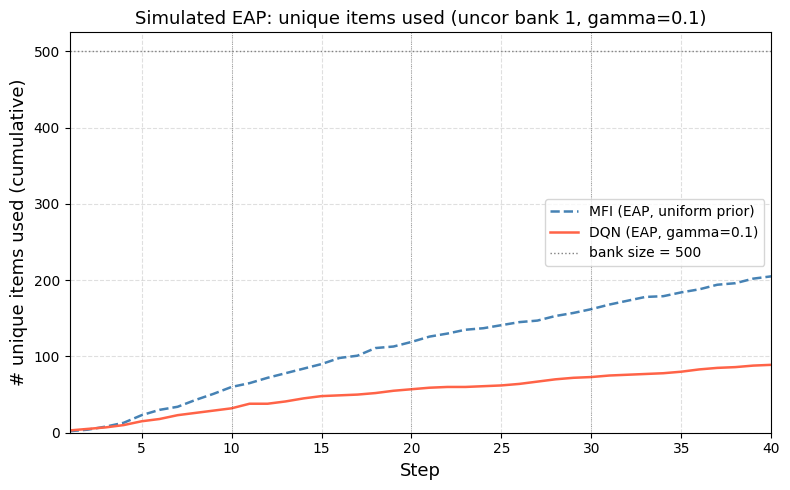

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/unique_items_used_gamma_0.1_sim_EAP.png


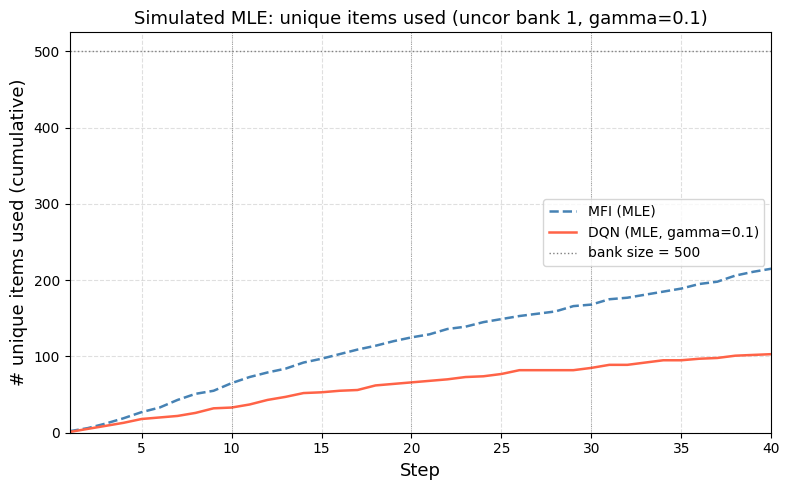

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/unique_items_used_gamma_0.1_sim_MLE.png


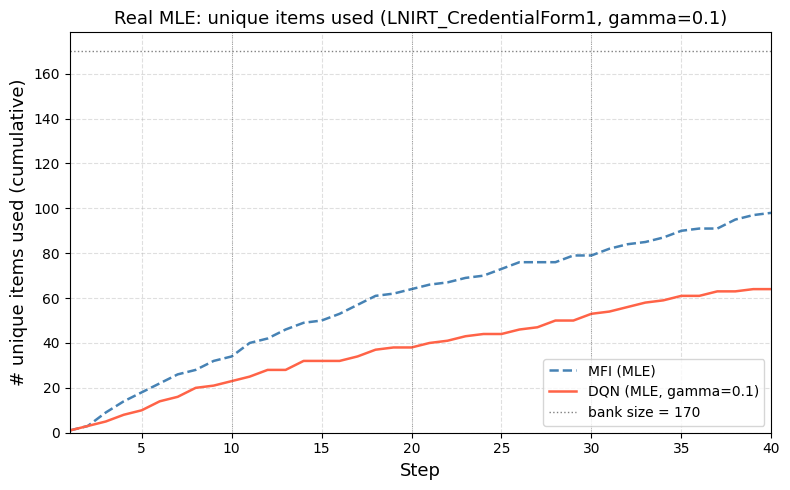

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/unique_items_used_gamma_0.1_real_MLE.png


In [5]:
# Also save each panel as its own figure for reuse.
for panel in panels:
    figure, axis = plt.subplots(figsize=(8, 5))
    for data, label, color, line_style in panel["series"]:
        if data is None:
            continue
        curve = curves[(panel["suffix"], label)]
        axis.plot(
            curve["step"],
            curve["unique_items"],
            label=label,
            color=color,
            linestyle=line_style,
            linewidth=1.8,
        )
    axis.axhline(
        panel["bank_size"],
        color="gray",
        linestyle=":",
        linewidth=1.0,
        label=f"bank size = {panel['bank_size']}",
    )
    for step in KEY_STEPS:
        axis.axvline(step, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    axis.set_xlabel("Step", fontsize=13)
    axis.set_ylabel("# unique items used (cumulative)", fontsize=13)
    axis.set_title(panel["title"], fontsize=13)
    axis.legend(fontsize=10, loc="best")
    axis.grid(True, linestyle="--", alpha=0.4)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.set_xlim(1, TEST_LENGTH)
    axis.set_ylim(bottom=0)

    figure.tight_layout()
    output_path = (
        EXP027_RESULTS / f"unique_items_used_gamma_{GAMMA}_{panel['suffix']}.png"
    )
    figure.savefig(output_path, dpi=150)
    plt.show()
    print(f"Saved to: {output_path}")

In [6]:
# Persist the per-step cumulative counts as a single tidy CSV.
tidy_rows = []
for (suffix, label), curve in curves.items():
    for _, row in curve.iterrows():
        tidy_rows.append(
            {
                "dataset": suffix,
                "method": label,
                "step": int(row["step"]),
                "unique_items": int(row["unique_items"]),
            }
        )
tidy = pd.DataFrame(tidy_rows)
tidy_path = EXP027_RESULTS / f"unique_items_used_gamma_{GAMMA}.csv"
tidy.to_csv(tidy_path, index=False)
print(f"Saved tidy CSV to: {tidy_path}")
print(tidy.head())

Saved tidy CSV to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/unique_items_used_gamma_0.1.csv
   dataset                    method  step  unique_items
0  sim_EAP  MFI (EAP, uniform prior)     1             2
1  sim_EAP  MFI (EAP, uniform prior)     2             4
2  sim_EAP  MFI (EAP, uniform prior)     3             8
3  sim_EAP  MFI (EAP, uniform prior)     4            13
4  sim_EAP  MFI (EAP, uniform prior)     5            23
